# Sello 9 — Correlación vs. causalidad

### ¿El clima o la música "causan" más ventas?

**Pregunta de negocio del sello:** ¿El clima *causa* que se venda más bebida caliente?

> Proyecto Final Integrador · TCNT0011 Probabilidad y Estadística I · Café Cordillera
> 
> Método: tabla de contingencia, prueba chi-cuadrado de independencia, Cramér's V y análisis de variables confusoras.

## 1. Datos

Cargamos `cafe_cordillera_dataset.csv` (11,983 transacciones). Este sello trabaja con `clima` y `categoria`, y usa `hora` y `sucursal` como apoyo para discutir confusores.

In [1]:
import os
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from scipy import stats

for _p in ["cafe_cordillera_dataset.csv", "../cafe_cordillera_dataset.csv"]:
    if os.path.exists(_p):
        DATA_PATH = _p
        break

df = pd.read_csv(DATA_PATH)
print(f"Filas: {df.shape[0]:,} · Columnas: {df.shape[1]}")
print(df.head(3).to_string(index=False))

Filas: 11,983 · Columnas: 15
 id_transaccion  id_pedido  id_cliente      fecha  hora sucursal producto   categoria  precio_unitario  unidades  medio_pago    clima  promocion_activa promocion_tipo  calificacion_satisfaccion
              1       2033         697 2026-03-02     6  Cartago Limonada bebida_fria             1284         1     tarjeta lluvioso                 0            NaN                        NaN
              2       2033         697 2026-03-02     6  Cartago  Galleta      postre              841         1 sinpe_movil lluvioso                 0            NaN                        NaN
              3       2033         697 2026-03-02     6  Cartago   Frappe bebida_fria             1785         1 sinpe_movil lluvioso                 0            NaN                        NaN


In [2]:
print("Clima:")
print(df["clima"].value_counts().to_string())
print("\nCategoría:")
print(df["categoria"].value_counts().to_string())

Clima:
clima
soleado     4575
nublado     4132
lluvioso    3276

Categoría:
categoria
bebida_fria        5457
bebida_caliente    4035
postre             1732
snack               759


## 2. ¿Existe relación entre clima y categoría?

Construimos la **tabla de contingencia**: cuántas transacciones de cada categoría ocurren bajo cada clima, en conteos y en proporción.

In [3]:
tabla = pd.crosstab(df["clima"], df["categoria"])
print("Conteos:\n", tabla.to_string())
print("\nProporción por clima (suma por fila = 1):")
print(tabla.div(tabla.sum(axis=1), axis=0).round(3).to_string())

Conteos:
 categoria  bebida_caliente  bebida_fria  postre  snack
clima                                                 
lluvioso              1374         1188     509    205
nublado               1295         1995     572    270
soleado               1366         2274     651    284

Proporción por clima (suma por fila = 1):
categoria  bebida_caliente  bebida_fria  postre  snack
clima                                                 
lluvioso             0.419        0.363   0.155  0.063
nublado              0.313        0.483   0.138  0.065
soleado              0.299        0.497   0.142  0.062


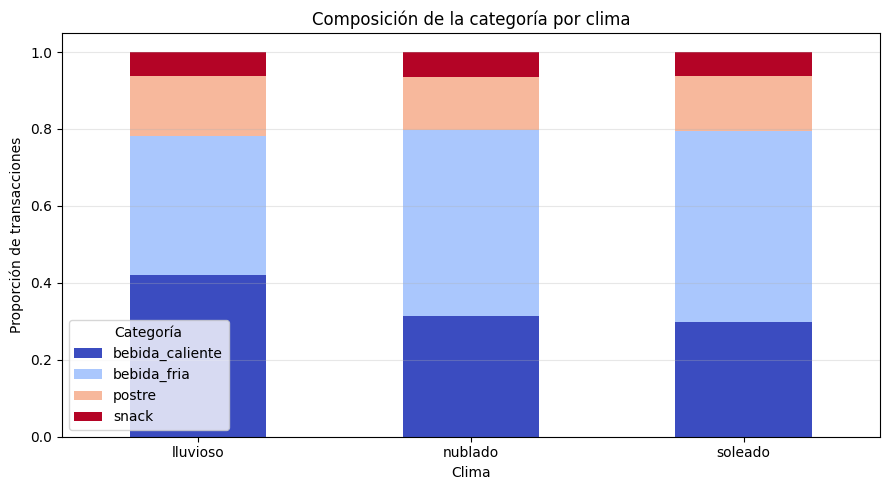

In [4]:
proporciones = tabla.div(tabla.sum(axis=1), axis=0)
ax = proporciones.plot(kind="bar", stacked=True, figsize=(9, 5), colormap="coolwarm")
ax.set_title("Composición de la categoría por clima")
ax.set_ylabel("Proporción de transacciones")
ax.set_xlabel("Clima")
ax.legend(title="Categoría")
ax.grid(axis="y", alpha=0.3)
plt.xticks(rotation=0)
plt.tight_layout()
plt.show()

## 3. Chi-cuadrado e intensidad de la relación

El **chi-cuadrado de independencia** indica si la asociación es estadísticamente significativa. **Cramér's V** mide la fuerza de la asociación (0 = independencia, 1 = dependencia perfecta).

In [5]:
chi2, p, dof, _ = stats.chi2_contingency(tabla)
n = tabla.values.sum()
cramers_v = np.sqrt((chi2 / n) / (min(tabla.shape) - 1))
print(f"Chi-cuadrado = {chi2:.2f}  ·  g.l. = {dof}  ·  p = {p:.3e}")
print(f"Cramér's V = {cramers_v:.4f}")
print("Interpretación: V < 0.10 es una asociación débil.")

Chi-cuadrado = 183.40  ·  g.l. = 6  ·  p = 6.417e-37
Cramér's V = 0.0875
Interpretación: V < 0.10 es una asociación débil.


## 4. Lo que le importa a la gerencia

¿La bebida caliente se vende proporcionalmente más en días lluviosos? ¿Y el volumen (unidades) cambia con el clima?

In [6]:
share_caliente = df.groupby("clima")["categoria"].apply(
    lambda s: (s == "bebida_caliente").mean()
)
print("Proporción de bebida caliente por clima:")
print(share_caliente.round(3).to_string())

print("\nUnidades promedio por clima:")
print(df.groupby("clima")["unidades"].mean().round(3).to_string())

Proporción de bebida caliente por clima:
clima
lluvioso    0.419
nublado     0.313
soleado     0.299

Unidades promedio por clima:
clima
lluvioso    1.456
nublado     1.423
soleado     1.420


## 5. Correlación ≠ causalidad: variables confusoras

Los datos muestran una **asociación** real y significativa entre clima y categoría. Pero eso **no** prueba que el clima *cause* las ventas. Variables ocultas (confusoras) pueden explicar la misma relación:

- **Hora del día:** el mix de bebida caliente/fría depende del momento del día. Si los días lluviosos concentran compras en la mañana, la "causa" aparente no es el clima sino la hora.
- **Promociones:** si las promociones coinciden con días lluviosos, el aumento de ventas vendría de la promoción, no del clima.
- **Sucursal y hábitos de zona:** cada sucursal tiene su mix de clientes.
- La **música** del ejemplo de clase: si en días lluviosos se pone otro playlist, la música *correlaciona* con las ventas sin causarlas — es una correlación espuria.

Comprobamos el confusor de la hora en los propios datos:

In [7]:
share_hora = df.groupby("hora")["categoria"].apply(
    lambda s: (s == "bebida_caliente").mean()
)
print("Proporción de bebida caliente por hora:")
print(share_hora.round(3).to_string())

manana = df[df["hora"] <= 10]
tarde = df[df["hora"] >= 11]
print(f"\nMañana (hora ≤ 10): {(manana['categoria'] == 'bebida_caliente').mean():.3f}")
print(f"Tarde  (hora ≥ 11): {(tarde['categoria'] == 'bebida_caliente').mean():.3f}")

Proporción de bebida caliente por hora:
hora
6     0.318
7     0.335
8     0.332
9     0.326
10    0.337
11    0.311
12    0.333
13    0.332
14    0.374
15    0.376
16    0.332
17    0.343
18    0.345
19    0.357

Mañana (hora ≤ 10): 0.330
Tarde  (hora ≥ 11): 0.342


## 6. Conclusión (lenguaje de negocio)

Los datos muestran una asociación **significativa pero débil** entre clima y categoría: en días lluviosos la bebida caliente pasa de ~30 % a ~42 % de las transacciones (chi-cuadrado p < 0.001, Cramér's V ≈ 0.09). Sin embargo, **no podemos afirmar que el clima cause esas ventas**: la hora del día, las promociones y el perfil de cada sucursal son variables confusoras que pueden producir la misma relación sin causalidad directa. La recomendación es usar el clima como **señal de pronóstico** (planear stock de bebida caliente en días lluviosos) y no como **causa** para justificar decisiones de precio o inversión.